In [1]:
import matplotlib as mpl
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import numpy as np
import pandas as pd
from pathlib import Path
from scipy.stats import spearmanr

import os
from dotenv import load_dotenv
load_dotenv()
tcr_toolbox_path = os.getenv('tcr_toolbox_path')
from tcr_toolbox.utils.plot_utils import startfig, set_mpl_params, view_color_dict
mpl, mylines = set_mpl_params(mpl=mpl)

In [2]:
def normalize_plate(df):
    control_mean = df.loc[df["is_control"], "target_div_filler"].mean()
    df["target_div_filler_norm"] = df["target_div_filler"] / control_mean * 100
    return df

## Fig. 5b

In [ ]:
data_dir = Path('/experiments/4_ym_mm_Ag_T_100_200_validation_CD69_killing/3_4_Killing_CCSER2_2024.06/3_4_3_killing/20240704_killing')
outs_dir = Path('/v1/figures/fig_5_pdfs')

In [4]:
ccser2_killing_df = pd.read_excel(data_dir / "YM20240704_CCSER2_killing.xlsx")

In [5]:
ccser2_killing_df

,file,target,filler,Ratio,Normalize,Unnamed: 5
0,20240704_plate1_B cell control.fcs,0.679,0.318,2.135220,1.000000,NaN
1,20240704_plate1_parental_0.fcs,0.664,0.335,1.982090,0.928283,NaN
2,20240704_plate1_parental_10_24.fcs,0.667,0.332,2.009036,0.940904,NaN
3,20240704_plate1_parental_25_6.fcs,0.676,0.322,2.099379,0.983214,NaN
4,20240704_plate1_parental_64.fcs,0.699,0.299,2.337793,1.094872,NaN
...,...,...,...,...,...,...
103,20240704_single stain_mKelly1.fcs,0,0,NaN,NaN,NaN
104,20240704_single stain_no_stain_B.fcs,0,1,0.000000,NaN,NaN
105,20240704_single stain_no_stain_T.fcs,0.556,0.444,1.252252,NaN,NaN
106,Mean,35.3 %,60.5 %,NaN,NaN,NaN


In [6]:
ccser2_killing_df.drop("Unnamed: 5", axis = 1, inplace = True)
ccser2_killing_df = ccser2_killing_df.iloc[0:105, :].copy()
ccser2_killing_df["Plate"] = (
    ccser2_killing_df["file"]
    .str.extract(r"(20240704_plate\s*\d+)")[0]
    .str.replace(r"\s+", "", regex=True)
)
ccser2_killing_df[["Sample", "Concentration"]] = ccser2_killing_df["file"].str.extract(
    r"20240704_plate\s*\d+_([^_]+(?: [^_]+)?)_?([^\.]*)\.fcs"
)
ccser2_killing_df["is_control"] = ccser2_killing_df["file"].str.contains(
    r"B cell control", case=False, regex=True
)

In [7]:
ccser2_killing_df["Sample"].unique()

array(['B cell control', 'parental', 'target', '5-7', '8-11', '9-17',
       '40-76', '44-80', '76-150', '96-188', nan], dtype=object)

In [8]:
ccser2_killing_df.dropna(subset = ["Sample"], inplace = True)

In [9]:
dose_map_dict = {"0": 4.096, "10_24": 10.24, "25_6": 25.6, "64": 64, "160": 160, "400": 400}

In [10]:
ccser2_killing_df["target_div_filler"] = (
    ccser2_killing_df["target"] / ccser2_killing_df["filler"]
)

ccser2_killing_df = (
    ccser2_killing_df.groupby("Plate").apply(normalize_plate, include_groups=False)
    .reset_index(level=0)  # promotes Plate back from index to column
    .reset_index(drop=True)
)
# Remove 'target' and 'B cell control' samples
ccser2_killing_df = ccser2_killing_df[
    ~ccser2_killing_df["file"].str.contains(
        r"target|B cell control", case=False, regex=True
    )
].copy()


# ccser2_killing_df["Dose_idx"] = ccser2_killing_df.groupby(["Sample", "Plate"]).cumcount()
# x_values = [4.096, 10.24, 25.60, 64, 160, 400, 1000]
# dose_map = dict(zip(range(len(x_values) - 1), x_values[:-1]))
ccser2_killing_df["Dose_val"] = ccser2_killing_df["Concentration"].map(dose_map_dict)
if ccser2_killing_df["Dose_val"].isna().any():
    raise Exception("Dose_val contains missing values!")

# Keep experimental data
experimental_df = ccser2_killing_df[
    ["Sample", "Plate", "Dose_val", "target_div_filler_norm"]
].copy()

# Add control row per Sample (last x_value = no T cell)
control_rows = []
for sample in experimental_df["Sample"].unique():
    control_rows.append(
        {
            "Sample": sample,
            "Plate": "control",
            "Dose_val": 1000,
            "target_div_filler_norm": 100,
        }
    )
control_df = pd.DataFrame(control_rows)

In [ ]:
reactive_df = pd.read_excel('/data/200_vs_200_run-1-2_run-2_combined/outs/200vs200-r1-2-r2/reactive_pair_df_200vs200-r1-2-r2.xlsx', index_col = 0)

In [ ]:
reactive_df = reactive_df.loc[:, ["TCR", "Pair", "P_value_corrected", "Fold_change", "Epitope"]]

In [13]:
reactive_df["-log10_P_value_corrected"] = -np.log10(reactive_df["P_value_corrected"])

In [14]:
# Combine experimental and control
full_df = pd.concat([experimental_df, control_df], ignore_index=True)

# Aggregate across plates (mean & std)
agg_df = (
    full_df.groupby(["Sample", "Dose_val"], as_index=False)["target_div_filler_norm"]
    .agg(["mean", "std"])
    .reset_index(drop = True)
)
agg_df["std"] = agg_df["std"].fillna(0)

In [15]:
agg_df["TCR"] = ["tcr_" + sample if sample != "parental" else "parental" for sample in agg_df["Sample"]]
agg_df["TCR"] = agg_df["TCR"].str.replace("-", "_")
reactive_agg_df = pd.merge(agg_df, reactive_df, on = "TCR", how = "left")
reactive_agg_df["-log10_P_value_corrected_sort"] = reactive_agg_df["-log10_P_value_corrected"].fillna(0)

sample_order = (
    reactive_agg_df.groupby("Sample")["-log10_P_value_corrected_sort"]
    .mean()
    .sort_values(ascending=True)
    .index
)
reactive_agg_df["Sample"] = pd.Categorical(
    reactive_agg_df["Sample"],
    categories=sample_order,
    ordered=True
)

# Re-order the rows based on the categorical
reactive_agg_df = reactive_agg_df.sort_values("Sample")


In [16]:
plot_dose_list = [4.096, 10.24, 25.60, 64, 160, 400, 1000]

In [ ]:
reactive_agg_df.loc[(reactive_agg_df["Epitope"] == "epi_mel-pt-a_CCSER2_1384") & (reactive_agg_df["Dose_val"] == 400), :].sort_values("mean")

628.6087978757513


/var/folders/w6/4g13dtn528z_gtdhwddhyqz5hrjw4d/T/ipykernel_87976/418191634.py:5: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  viridis = cm.get_cmap("viridis")
/var/folders/w6/4g13dtn528z_gtdhwddhyqz5hrjw4d/T/ipykernel_87976/418191634.py:17: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for sample, subset_df in reactive_agg_df.groupby("Sample"):


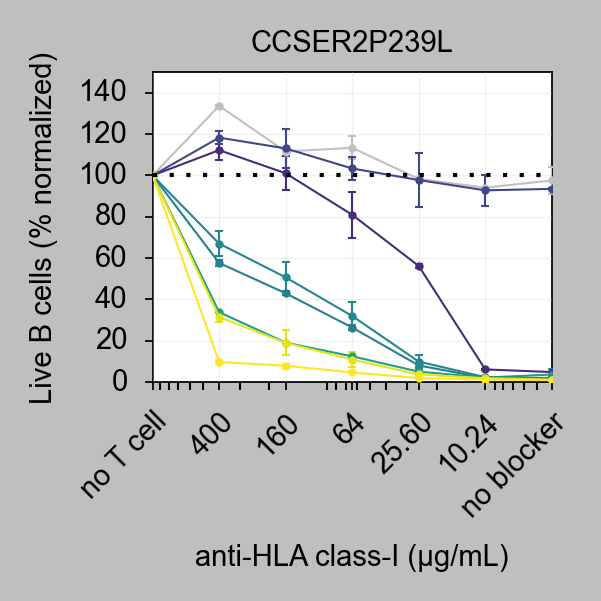

In [ ]:
print(reactive_df["Fold_change"].quantile(0.95))
norm = mcolors.Normalize(vmin=0, vmax=reactive_df.loc[:, "Fold_change"].quantile(0.95))
viridis = cm.get_cmap("viridis")

def get_color(row):
    if "parental" in row["TCR"]:
        return "silver"
    if pd.isna(row["Fold_change"]):
        return "silver"
    return viridis(norm(row["Fold_change"]))

# Plot
ax, fig, gs = startfig(5.5, 5.5)

for sample, subset_df in reactive_agg_df.groupby("Sample"):
    subset_df = subset_df.sort_values("Dose_val")
    first_row = subset_df.iloc[0]
    ax.errorbar(
        subset_df["Dose_val"],
        subset_df["mean"],
        yerr=subset_df["std"],
        marker="o",
        capsize=1,
        markersize=2,
        linestyle="-",
        label=sample,
        color=get_color(first_row),
        linewidth=0.5,
        markeredgecolor="none",
        zorder = 4
    )

# Add colorbar for viridis scale
sm = cm.ScalarMappable(cmap=viridis, norm=norm)
sm.set_array([])


ax.set_ylim(0, 150)
ax.axhline(y=100, color="black", linestyle="dotted", linewidth=1, zorder=20)
ax.tick_params(axis="y", labelsize=7)
ax.tick_params(top=False, right=False)
ax.tick_params(which = "minor", top=False)
ax.set_xscale("log")
ax.set_xticks(plot_dose_list)
ax.set_xticklabels(
    ["no blocker", "10.24", "25.60", "64", "160", "400", "no T cell"],
    fontsize=7, rotation=45, ha="right", rotation_mode="anchor",
)
ax.set_xlim(min(plot_dose_list), max(plot_dose_list))
ax.invert_xaxis()
ax.set_title("CCSER2P239L", fontsize=7)
ax.set_xlabel("anti-HLA class-I (µg/mL)", fontsize=7)
ax.set_ylabel("Live B cells (% normalized)", fontsize=7)
ax.grid(True, alpha=0.3, zorder = -4)
fig.tight_layout()
fig.savefig(outs_dir / "CCSER2_P239L_B_cell_viability_vs_aMHC_blocker.pdf")

In [19]:
print(
    agg_df.groupby("Sample")["Dose_val"].nunique()
)

# keep only real dose response points
auc_input_df = agg_df[
    (agg_df["Dose_val"] > 4.096) &
    (agg_df["Dose_val"] < 1000)
].copy()

auc_list = []

for sample, subset in auc_input_df.groupby("Sample"):

    subset = subset.sort_values("Dose_val")

    # x = log10 dose
    x = np.log10(subset["Dose_val"].astype(float).values)

    # y = normalized viability
    y = subset["mean"].astype(float).values

    auc = np.trapezoid(y, x)

    auc_list.append(
        {
            "Sample": sample,
            "AUC": auc
        }
    )

ccser2_auc_df = pd.DataFrame(auc_list)

# parental reference
parental_auc = ccser2_auc_df.loc[
    ccser2_auc_df["Sample"].str.contains("parental", case=False),
    "AUC"
].mean()

# normalize to parental
ccser2_auc_df["AUC_norm"] = ccser2_auc_df["AUC"] / parental_auc * 100

# optional: killing score (easier to read)
ccser2_auc_df["Killing_score"] = 100 - ccser2_auc_df["AUC_norm"]
ccser2_auc_df.sort_values("AUC_norm", inplace = True)

print(ccser2_auc_df)

ccser2_auc_df.to_excel(
    data_dir / "ccser2_killing_AUC_normalized.xlsx",
    index=False
)

Sample
40-76       7
44-80       7
5-7         7
76-150      7
8-11        7
9-17        7
96-188      7
parental    7
Name: Dose_val, dtype: int64
     Sample         AUC    AUC_norm  Killing_score
2       5-7    7.900361    4.540786      95.459214
5      9-17   19.941347   11.461423      88.538577
3    76-150   21.683209   12.462570      87.537430
4      8-11   42.641901   24.508720      75.491280
0     40-76   50.614986   29.091304      70.908696
1     44-80  118.350409   68.022695      31.977305
6    96-188  167.075274   96.027639       3.972361
7  parental  173.986652  100.000000       0.000000


In [ ]:
reactive_df = reactive_df.merge(
    ccser2_auc_df[["AUC_norm", "TCR"]],
    on="TCR",
    how="left"
)

reactive_df.set_index("TCR", inplace=True)
reactive_df.reset_index(inplace=True)
reactive_plot_df = reactive_df.dropna(subset = ["AUC_norm"])

In [ ]:
reactive_plot_df = reactive_plot_df.loc[reactive_plot_df["Epitope"] == "epi_mel-pt-a_CCSER2_1384", :]
ax,fig,gs = startfig(5, 5.25)

x = reactive_plot_df["Fold_change"].values
y = 100 - reactive_plot_df["AUC_norm"].values

n_boot = 10000
boot_r = []

for i in range(n_boot):
    idx = np.random.choice(len(x), len(x), replace=True)
    r, _ = spearmanr(x[idx], y[idx])
    boot_r.append(r)

boot_r = np.array(boot_r)
ci_low, ci_high = np.percentile(boot_r, [2.5, 97.5])

ax.scatter(x, y, 
           c=reactive_plot_df["Fold_change"],
           cmap=viridis,
           norm=norm,
           edgecolors= 'none', 
           s= 7)
res = spearmanr(reactive_plot_df["Fold_change"], 100-reactive_plot_df["AUC_norm"])
ax.set_title(f"R={round(res.statistic, 2)} [{round(ci_low, 2)}, {round(ci_high,2)}], P={round(res.pvalue, 3)}", fontsize = 7)
ax.tick_params('both', labelsize = 7)
ax.set_xlabel("Fold change\nMel-Pt-A 200 vs 200 screen", fontsize = 7)
ax.set_ylabel("Killed B cells (% normalized)", fontsize = 7)
ax.tick_params(axis="x", rotation=90, pad=1)
# ax.spines["top"].set_visible(False)
# ax.spines["right"].set_visible(False)
ax.tick_params(top=False, right=False)
ax.set_ylim(0, 100)
fig.tight_layout()
fig.savefig(outs_dir / "killed_b_cells_vs_fold_change_200_vs_200_screen_scatter_ccser2.pdf")

## Fig. 5e, Mel-Pt-B BBS12

In [ ]:
data_dir = Path('/experiments/19_mel-pt-b_killing/killing FACS data/mel-pt-b killing assay/')
outs_dir = Path('/v1/figures/fig_5_pdfs')

In [ ]:
bbs12_killing_df = pd.read_excel(data_dir / "mel-pt-b_killing_FACS_result.xlsx")

In [42]:
bbs12_killing_df = bbs12_killing_df[["file", "TCR", 'target', "filler"]]

In [43]:
bbs12_killing_df = bbs12_killing_df.dropna(subset=["file"]).copy()
bbs12_killing_df["Sample"] = bbs12_killing_df["file"].str.extract(r"^([^_]+)")
bbs12_killing_df["TCR"] = bbs12_killing_df["TCR"].fillna("parental")
bbs12_killing_df["Concentration"] = bbs12_killing_df["file"].str.extract(r"MHC block ([^\.]+)\.fcs")
bbs12_killing_df["is_control"] = bbs12_killing_df["file"].str.contains(r"filler\s*\+\s*target", case=False, regex=True)

dose_map = {"0": 4.096, "10-24": 10.24, "25-6": 25.6, "64": 64, "160": 160, "400": 400}
bbs12_killing_df["Dose_val"] = bbs12_killing_df["Concentration"].map(dose_map)
bbs12_killing_df["target_div_filler"] = bbs12_killing_df["target"] / bbs12_killing_df["filler"]

In [44]:
control_value = bbs12_killing_df.loc[bbs12_killing_df["is_control"], "target_div_filler"].mean()
bbs12_killing_df["target_div_filler_norm"] = bbs12_killing_df["target_div_filler"] / control_value * 100
bbs12_killing_df = bbs12_killing_df[~bbs12_killing_df["is_control"]].copy()

In [45]:
agg_df = (
    bbs12_killing_df.groupby(["Sample", "TCR", "Dose_val"])["target_div_filler_norm"]
    .agg(["mean", "std"])
    .reset_index()
)

In [46]:
control_rows = [
    {"Sample": s, "TCR": t, "Dose_val": 1000, "mean": 100, "std": 0}
    for s, t in agg_df[["Sample", "TCR"]].drop_duplicates().values
]
agg_df = pd.concat([agg_df, pd.DataFrame(control_rows)], ignore_index=True)

In [ ]:
reactive_df = pd.read_excel('/data/mel-pt-b_run-1_run-2_counts_combined/outs/mel-pt-b-r1-r2/reactive_pair_df_mel-pt-b-r1-r2.xlsx')
merged_df = pd.merge(
    agg_df,
    reactive_df[["TCR", "Fold_change"]],
    on="TCR",
    how="left"
)

In [48]:
sample_order = [
    "parental-B7",
    "T28-B7",
    "T26-B3",
    "T23-B3",
]

merged_df["Sample"] = pd.Categorical(
    merged_df["Sample"],
    categories=sample_order,
    ordered=True
)

merged_df = merged_df.sort_values(["Sample", "Dose_val"])

346.0406186535772
parental-b7
t28-b7
t26-b3
t23-b3


/var/folders/w6/4g13dtn528z_gtdhwddhyqz5hrjw4d/T/ipykernel_46178/4241092856.py:5: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  viridis = cm.get_cmap("viridis")
/var/folders/w6/4g13dtn528z_gtdhwddhyqz5hrjw4d/T/ipykernel_46178/4241092856.py:28: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for sample, subset_df in merged_df.groupby("Sample"):


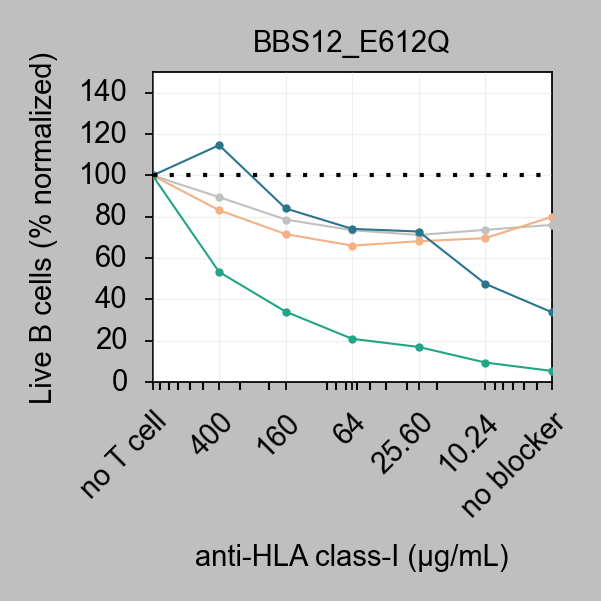

In [ ]:
print(reactive_df["Fold_change"].quantile(0.95))
norm = mcolors.Normalize(vmin=0, vmax=reactive_df["Fold_change"].quantile(0.95))
viridis = cm.get_cmap("viridis")

def get_color(row):
    sample_name = str(row["Sample"]).lower()
    print(sample_name)
    # NEGATIVE CONTROL → light orange
    if "t28-b7" in sample_name:
        return "#f4b183"

    # parental-B7 → silver
    elif "parental-b7" in sample_name:
        return "silver"

    # missing fold change → silver
    elif pd.isna(row["Fold_change"]):
        return "silver"

    else:
        return viridis(norm(row["Fold_change"]))

# Plot
ax, fig, gs = startfig(5.5, 5.5)

for sample, subset_df in merged_df.groupby("Sample"):
    subset_df = subset_df.sort_values("Dose_val")
    first_row = subset_df.iloc[0]
    #print(first_row)
    ax.errorbar(
        subset_df["Dose_val"],
        subset_df["mean"],
        yerr=subset_df["std"],
        marker="o",
        capsize=1,
        markersize=2,
        linestyle="-",
        label=sample,
        color=get_color(first_row),
        linewidth=0.5,
        markeredgecolor="none",
        zorder = 4
    )

# Add colorbar for viridis scale
sm = cm.ScalarMappable(cmap=viridis, norm=norm)
sm.set_array([])


ax.set_ylim(0, 150)
ax.axhline(y=100, color="black", linestyle="dotted", linewidth=1, zorder=20)
ax.tick_params(axis="y", labelsize=7)
ax.tick_params(top=False, right=False)
ax.tick_params(which = "minor", top=False)
ax.set_xscale("log")
ax.set_xticks(plot_dose_list)
ax.set_xticklabels(
    ["no blocker", "10.24", "25.60", "64", "160", "400", "no T cell"],
    fontsize=7, rotation=45, ha="right", rotation_mode="anchor",
)
ax.set_xlim(min(plot_dose_list), max(plot_dose_list))
ax.invert_xaxis()
ax.set_title("BBS12_E612Q", fontsize=7)
ax.set_xlabel("anti-HLA class-I (µg/mL)", fontsize=7)
ax.set_ylabel("Live B cells (% normalized)", fontsize=7)
ax.grid(True, alpha=0.3, zorder = -4)
fig.tight_layout()
fig.savefig(outs_dir / "BBS12_E612Q_B_cell_viability_vs_aMHC_blocker.pdf")

In [50]:
print(
    agg_df.groupby("Sample")["Dose_val"].nunique()
)

# keep only real dose response points
auc_input_df = agg_df[
    (agg_df["Dose_val"] > 4.096) &
    (agg_df["Dose_val"] < 1000)
].copy()

auc_list = []

for sample, subset in auc_input_df.groupby("Sample"):

    subset = subset.sort_values("Dose_val")

    # x = log10 dose
    x = np.log10(subset["Dose_val"].astype(float).values)

    # y = normalized viability
    y = subset["mean"].astype(float).values

    auc = np.trapezoid(y, x)

    auc_list.append(
        {
            "Sample": sample,
            "AUC": auc, 
            "TCR": subset["TCR"].unique()[0]
        }
    )

bbs12_auc_df = pd.DataFrame(auc_list)

# parental reference
parental_auc = bbs12_auc_df.loc[
    bbs12_auc_df["Sample"].str.contains("parental", case=False),
    "AUC"
].mean()

# normalize to parental
bbs12_auc_df["AUC_norm"] = bbs12_auc_df["AUC"] / parental_auc * 100

# optional: killing score (easier to read)
bbs12_auc_df["Killing_score"] = 100 - bbs12_auc_df["AUC_norm"]
bbs12_auc_df.sort_values("AUC_norm", inplace = True)

Sample
T23-B3         7
T26-B3         7
T28-B7         7
parental-B7    7
Name: Dose_val, dtype: int64


In [51]:
reactive_plot_df = reactive_df.merge(
    bbs12_auc_df[["AUC_norm", "TCR"]],
    on="TCR",
    how="left"
)


/var/folders/w6/4g13dtn528z_gtdhwddhyqz5hrjw4d/T/ipykernel_46178/993337101.py:12: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r, _ = spearmanr(x[idx], y[idx])


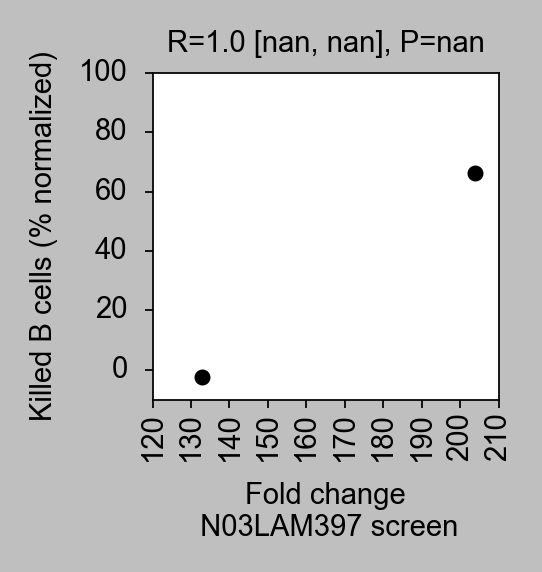

In [ ]:
reactive_plot_df = reactive_plot_df.loc[reactive_plot_df["Epitope"] == "epi_mel-pt-b_BBS12_E612Q_432", :]
ax,fig,gs = startfig(5, 5.25)

x = reactive_plot_df["Fold_change"].values
y = reactive_plot_df["AUC_norm"].values

n_boot = 10000
boot_r = []

for i in range(n_boot):
    idx = np.random.choice(len(x), len(x), replace=True)
    r, _ = spearmanr(x[idx], y[idx])
    boot_r.append(r)

boot_r = np.array(boot_r)
ci_low, ci_high = np.percentile(boot_r, [2.5, 97.5])

ax.scatter(reactive_plot_df["Fold_change"], 100-reactive_plot_df["AUC_norm"], 
           color = "black", 
           s= 8)
res = spearmanr(reactive_plot_df["Fold_change"], 100-reactive_plot_df["AUC_norm"])
ax.set_title(f"R={round(res.statistic, 2)} [{round(ci_low, 2)}, {round(ci_high,2)}], P={round(res.pvalue, 3)}", fontsize = 7)
ax.tick_params('both', labelsize = 7)
ax.set_xlabel("Fold change\n Mel-Pt-B screen", fontsize = 7)
ax.set_ylabel("Killed B cells (% normalized)", fontsize = 7)
ax.tick_params(axis="x", rotation=90, pad=1)
ax.set_ylim(-10, 100)
# ax.spines["top"].set_visible(False)
# ax.spines["right"].set_visible(False)
ax.tick_params(top=False, right=False)
fig.tight_layout()
fig.savefig(outs_dir / "killed_b_cells_vs_fold_change_mel-pt-b_96_vs_781_screen_scatter_BBS12.pdf")

## Fig. 5d, D10 CCSER2mut incucyte confluency analysis

In [ ]:
data_dir = Path('/experiments/7_T200-Ag200_validation/Killing_assays/20250429_Data_D10Killing_Incucyte/Exported data')
outs_dir = Path('/v1/figures/fig_5_pdfs')

In [54]:
def load_timepoint(path, target_hours):
    df = pd.read_excel(path, header=None, keep_default_na=False)

    # Remove empty rows (common in imaging exports)
    df = df.replace("", pd.NA).dropna(how="all").reset_index(drop=True)

    hour_str = str(target_hours).split()[0]

    time_row_idx = None
    for idx, row in df.iterrows():
        row_str = " ".join(row.astype(str))

        if "Elapsed" not in row_str:
            continue

        if f" {hour_str} " in f" {row_str} ":
            time_row_idx = idx
            break

    if time_row_idx is None:
        raise ValueError(f"Time point {target_hours} not found in {path}")

    block = df.iloc[time_row_idx+1: time_row_idx+9].apply(pd.to_numeric, errors='coerce')
    block.reset_index(drop=True, inplace=True)
    return block

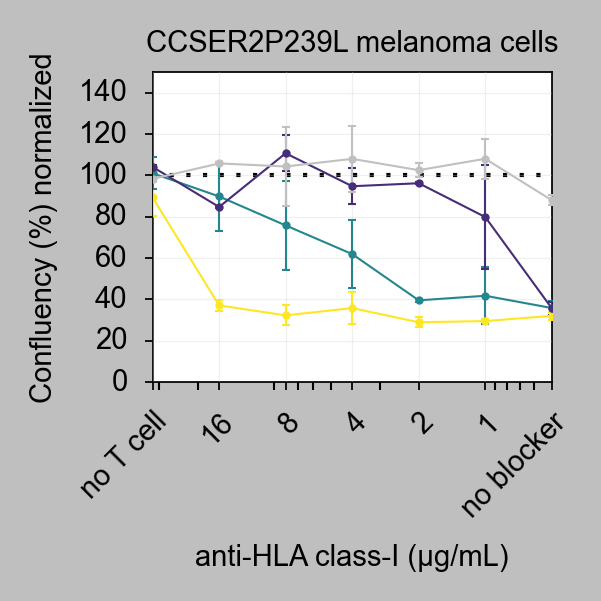

In [ ]:
target_hours = "48 hours"
baseline_hours = "0 hours"


# load relevant time point
confluency_plate1 = load_timepoint(
    data_dir / 'MM20250515_analysis_confluency1.xlsx',
    target_hours
)
confluency_plate2 = load_timepoint(
    data_dir / 'MM20250515_analysis_confluency2.xlsx',
    target_hours
)

# --- Subtract 0h baseline from 48h --- 
# confluency_plate1_delta = (confluency_plate1 - confluency_plate1_0).abs()
# confluency_plate2_delta = (confluency_plate2 - confluency_plate2_0).abs()

# Select relevant rows (if not substracting 0h baseline, add _delta)
confluency_plate1 = confluency_plate1.iloc[:7]
confluency_plate2 = confluency_plate2.iloc[:7]

# Set control
control_row1 = confluency_plate1.iloc[6]
control_row2 = confluency_plate2.iloc[6]

control1 = control_row1.mean()
control2 = control_row2.mean()

# Normalize to control
confluency_plate1_norm = (confluency_plate1.iloc[:, :4] / control1)*100
confluency_plate2_norm = (confluency_plate2.iloc[:, :4] / control2)*100

# Stack duplicates along a new axis: shape becomes (7 rows, M columns, 2 duplicates)
stacked = np.stack([confluency_plate1_norm.values, confluency_plate2_norm.values], axis=2)

# Mean and std across the duplicate axis
mean_vals = stacked.mean(axis=2)
std_vals  = stacked.std(axis=2)

mean_df = pd.DataFrame(mean_vals, columns=confluency_plate1_norm.columns)
std_df  = pd.DataFrame(std_vals,  columns=confluency_plate2_norm.columns)

# Plot
x_values = [0.5, 1, 2, 4, 8, 16, 32]  
x_labels = ["no blocker", "1", "2", "4", "8", "16", "no T cell"]

column_names = ["TCR5_7", "TCR40_76", "TCR44_80", "untransduced"]
colors = ['salmon', 'gold', 'teal', 'grey']

mean_df.columns = column_names
std_df.columns  = column_names

def get_color(column_name):
    if column_name == "TCR5_7":
        return "#fde725" #"#fae500"
    elif column_name == "TCR40_76":  
        return "#24868e" #"#0d6d8a"
    elif column_name == "TCR44_80":
        return "#472c7a"#"#2f0a37"
    elif column_name == "untransduced":
        return "silver"
    else: 
        return "silver"
ax, fig, gs = startfig(5.5, 5.5)

for i, col in enumerate(column_names):
    mean = mean_df[col].values
    std  = std_df[col].values

    ax.errorbar(
        x_values,
        mean,
        yerr=std,
        marker="o",
        color = get_color(col),
        capsize=1,
        linewidth=0.5,
        markersize=2,
        linestyle="-",
        markeredgecolor="none",
        zorder = 4
    )

ax.set_xlabel("anti-HLA class-I (µg/mL)", fontsize=7)
ax.set_xscale('log')
ax.set_xticks(x_values)
ax.set_xticklabels(
    x_labels,
    fontsize=7, rotation=45, ha="right", rotation_mode="anchor",
)
ax.set_xlim(min(x_values), max(x_values))
ax.invert_xaxis()
ax.set_ylabel("Confluency (%) normalized", fontsize=7)
ax.tick_params(axis="y", labelsize=7)
ax.tick_params(top=False, right=False)
ax.tick_params(which = "minor", top=False)
ax.axhline(100, color='black', linestyle='dotted', linewidth=1)
ax.set_title("CCSER2P239L melanoma cells", fontsize=7)
ax.grid(True, alpha=0.3)
ax.set_ylim(0, 150)
#ax.legend(fontsize=7, loc="upper left")
fig.tight_layout()
fig.savefig(outs_dir / "D10_CCSER2mut_incucyte_killing_assay.pdf")



## Fig. 5f, KIAA1617 killing analysis

In [ ]:
data_dir = Path('/experiments/19_Mel-Pt-E_killing/killing FACS data/01052026 Mel-Pt-E killing/')
outs_dir = Path('/v1/figures/fig_5_pdfs')

In [ ]:
kia_killing_df = pd.read_excel(data_dir / "Mel-Pt-E_KIA_killing_facs_result.xlsx")

In [58]:
kia_killing_df.columns = kia_killing_df.columns.str.strip()
kia_killing_df.columns = kia_killing_df.columns.str.strip()
kia_killing_df.columns = kia_killing_df.columns.str.strip()

In [59]:
kia_killing_df = kia_killing_df.dropna(subset=["file"]).copy()
kia_killing_df["Sample"] = kia_killing_df["file"].str.extract(r"^([^_]+)")
kia_killing_df["TCR"] = kia_killing_df["TCR"].fillna("parental")
kia_killing_df["Concentration"] = kia_killing_df["file"].str.extract(r"_KIA_([^\.]+)\.fcs")
kia_killing_df["is_control"] = kia_killing_df["file"].str.contains(r"filler.*target", case=False, regex=True)
dose_map = {"0": 4.096, "10-24": 10.24, "25-6": 25.6, "64": 64, "160": 160, "400": 400}
kia_killing_df["Dose_val"] = kia_killing_df["Concentration"].map(dose_map)
kia_killing_df["target_div_filler"] = kia_killing_df["target"] / kia_killing_df["filler"]

In [60]:
control_value = kia_killing_df.loc[kia_killing_df["is_control"], "target_div_filler"].mean()
kia_killing_df["target_div_filler_norm"] = kia_killing_df["target_div_filler"] / control_value * 100
kia_killing_df = kia_killing_df[~kia_killing_df["is_control"]].copy()

In [61]:
agg_df = (
    kia_killing_df.groupby(["Sample", "TCR", "Dose_val"])["target_div_filler_norm"]
    .agg(["mean", "std"])
    .reset_index()
)

In [62]:
control_rows = [
    {"Sample": s, "TCR": t, "Dose_val": 1000, "mean": 100, "std": 0}
    for s, t in agg_df[["Sample", "TCR"]].drop_duplicates().values
]
agg_df = pd.concat([agg_df, pd.DataFrame(control_rows)], ignore_index=True)

In [ ]:
reactive_df = pd.read_excel('/outs/mel-pt-e/reactive_pair_df_mel-pt-e.xlsx')
merged_df = pd.merge(
    agg_df,
    reactive_df[["TCR", "Fold_change"]],
    on="TCR",
    how="left"
)

In [64]:
merged_df = merged_df.sort_values(["Sample", "Dose_val"])

In [ ]:
print(reactive_df["Fold_change"].quantile(0.95))
norm = mcolors.Normalize(vmin=0, vmax=reactive_df["Fold_change"].quantile(0.95))
viridis = cm.get_cmap("viridis")

def get_color(row):
    sample_name = str(row["Sample"]).lower()
    print(sample_name)
    # NEGATIVE CONTROL → light orange
    if "neg.control" in sample_name:
        return "#f4b183"

    # parental-B7 → silver
    elif "parental" in sample_name:
        return "silver"

    # missing fold change → silver
    elif pd.isna(row["Fold_change"]):
        return "silver"

    else:
        return viridis(norm(row["Fold_change"]))

# Plot
ax, fig, gs = startfig(5.5, 5.5)

for TCR, subset_df in merged_df.groupby("TCR"):
    subset_df = subset_df.sort_values("Dose_val")
    first_row = subset_df.iloc[0]
    #print(first_row)
    ax.errorbar(
        subset_df["Dose_val"],
        subset_df["mean"],
        yerr=subset_df["std"],
        marker="o",
        capsize=1,
        markersize=2,
        linestyle="-",
        label=TCR,
        color=get_color(first_row),
        linewidth=0.5,
        markeredgecolor="none",
        zorder = 4
    )

# Add colorbar for viridis scale
sm = cm.ScalarMappable(cmap=viridis, norm=norm)
sm.set_array([])


ax.set_ylim(0, 150)
ax.axhline(y=100, color="black", linestyle="dotted", linewidth=1, zorder=20)
ax.tick_params(axis="y", labelsize=7)
ax.tick_params(top=False, right=False)
ax.tick_params(which = "minor", top=False)
ax.set_xscale("log")
ax.set_xticks(plot_dose_list)
ax.set_xticklabels(
    ["no blocker", "10.24", "25.60", "64", "160", "400", "no T cell"],
    fontsize=7, rotation=45, ha="right", rotation_mode="anchor",
)
ax.set_xlim(min(plot_dose_list), max(plot_dose_list))
ax.invert_xaxis()
ax.set_title("KIAA1671_A1129V", fontsize=7)
ax.set_xlabel("anti-HLA class-I (µg/mL)", fontsize=7)
ax.set_ylabel("Live B cells (% normalized)", fontsize=7)
ax.grid(True, alpha=0.3, zorder = -4)
fig.tight_layout()
fig.savefig(outs_dir / "KIAA1671_A1129V_B_cell_viability_vs_aMHC_blocker.pdf")